# B2 用户行为分析
分析用户骑行频次、骑行时长/距离分布、Top10高频用户

In [20]:
import pandas as pd

# 读取原始文件
df_user = pd.read_csv('data/共享单车_用户特征.csv')

# 重命名列名
df_user.rename(columns={
    'frequency(次)': 'frequency',
    'total_distance(km)': 'total_distance',
    'total_duration(min)': 'total_duration',
    'avg_duration(min)': 'avg_duration',
    'avg_speed(km/h)': 'avg_speed'
}, inplace=True)

# 保存回文件（可选，覆盖原文件）
df_user.to_csv('data/共享单车_用户特征2.csv', index=False)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载订单和用户特征数据
df_ride = pd.read_csv('data/共享单车_清洗后.csv', parse_dates=['start_time', 'end_time'])
df_user = pd.read_csv('data/共享单车_用户特征2.csv')


print(f"使用列：频次={freq_col}, 总里程={dist_col}, 平均时长={dur_col}")

使用列：频次=frequency, 总里程=total_distance, 平均时长=total_duration


### 1. 用户骑行次数分布

count    16883.000000
mean         6.054019
std          3.476057
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         25.000000
Name: frequency, dtype: float64

低频(≤5次):8234人(48.8%)，中频(6-20):8640人，高频(>20):9人


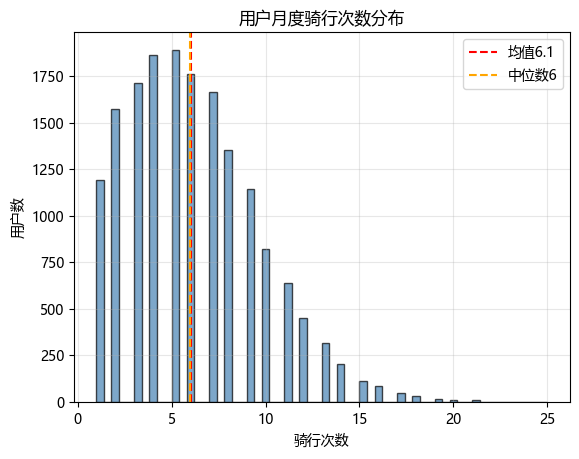

In [25]:
# 描述统计 + 分组统计
desc = df_user[freq_col].describe()
display(desc)
low = (df_user[freq_col] <= 5).sum()
mid = ((df_user[freq_col] > 5) & (df_user[freq_col] <= 20)).sum()
high = (df_user[freq_col] > 20).sum()
print(f"低频(≤5次):{low}人({low/len(df_user)*100:.1f}%)，中频(6-20):{mid}人，高频(>20):{high}人")

# 直方图
plt.hist(df_user[freq_col], bins=60, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(desc['mean'], color='red', linestyle='--', label=f"均值{desc['mean']:.1f}")
plt.axvline(desc['50%'], color='orange', linestyle='--', label=f"中位数{desc['50%']:.0f}")
plt.legend(); plt.title('用户月度骑行次数分布')
plt.xlabel('骑行次数'); plt.ylabel('用户数')
plt.grid(alpha=0.3); plt.show()

### 2. 骑行时长与距离分布

骑行时长描述：


count    102210.000000
mean         16.492917
std          16.017769
min           1.000000
25%           7.000000
50%          11.000000
75%          20.000000
max         180.000000
Name: duration_min, dtype: float64

骑行距离描述：


count    102210.000000
mean          1.557408
std           1.418243
min           0.146000
25%           0.723000
50%           1.126000
75%           1.882000
max          20.891000
Name: distance_km, dtype: float64

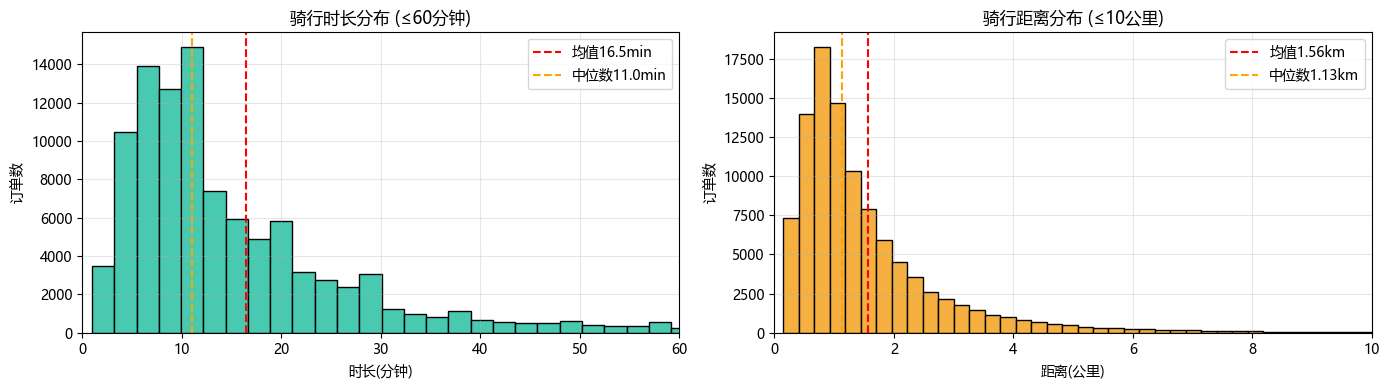

大多数骑行时长在20分钟以内，距离在3公里以内，符合短途接驳定位。


In [26]:
# 提取有效数据
duration = df_ride[dur_ride].dropna()
distance = df_ride[dist_ride].dropna()

print("骑行时长描述：")
display(duration.describe())
print("骑行距离描述：")
display(distance.describe())

# 创建并排子图（纯 plt 风格）
plt.figure(figsize=(14, 4))

# 子图1：时长分布
plt.subplot(1, 2, 1)
plt.hist(duration, bins=80, color='#48C9B0', edgecolor='black')
plt.axvline(duration.mean(), color='red', linestyle='--', label=f"均值{duration.mean():.1f}min")
plt.axvline(duration.median(), color='orange', linestyle='--', label=f"中位数{duration.median():.1f}min")
plt.xlim(0, 60)
plt.title('骑行时长分布 (≤60分钟)')
plt.xlabel('时长(分钟)')
plt.ylabel('订单数')
plt.legend()
plt.grid(alpha=0.3)

# 子图2：距离分布
plt.subplot(1, 2, 2)
plt.hist(distance, bins=80, color='#F5B041', edgecolor='black')
plt.axvline(distance.mean(), color='red', linestyle='--', label=f"均值{distance.mean():.2f}km")
plt.axvline(distance.median(), color='orange', linestyle='--', label=f"中位数{distance.median():.2f}km")
plt.xlim(0, 10)
plt.title('骑行距离分布 (≤10公里)')
plt.xlabel('距离(公里)')
plt.ylabel('订单数')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("大多数骑行时长在20分钟以内，距离在3公里以内，符合短途接驳定位。")

### 3. Top10 高频用户

,userid,frequency,total_distance,total_duration
0,6199,25,44.74,455.0
1,3369,23,33.06,312.0
2,4123,21,36.92,318.0
3,5150,21,30.35,418.0
4,5949,21,32.05,511.0
5,6138,21,47.79,412.0
6,6526,21,39.88,330.0
7,7475,21,26.73,287.0
8,8633,21,28.33,338.0
9,1123,20,30.93,463.0


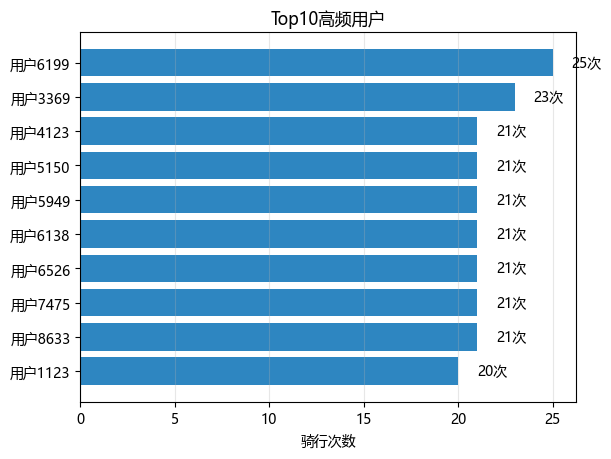

Top10用户贡献率：0.21%


In [27]:
top10 = df_user.nlargest(10, freq_col)[[uid_col, freq_col, dist_col, dur_col]].reset_index(drop=True)
display(top10)

plt.barh(range(10), top10[freq_col], color='#2E86C1')
plt.yticks(range(10), [f"用户{uid}" for uid in top10[uid_col]])
plt.xlabel('骑行次数'); plt.title('Top10高频用户')
plt.gca().invert_yaxis(); plt.grid(axis='x', alpha=0.3)
for i, v in enumerate(top10[freq_col]):
    plt.text(v+1, i, f'{int(v)}次', va='center')
plt.show()

total = df_user[freq_col].sum()
top_sum = top10[freq_col].sum()
print(f"Top10用户贡献率：{top_sum/total*100:.2f}%")